In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\User\OneDrive\Desktop\Hazardous_Asteroid_Project\neo (3).csv")

In [2]:
df.head()

,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


In [3]:
df.shape

(90836, 10)

In [4]:
df.columns

Index(['id', 'name', 'est_diameter_min', 'est_diameter_max',
       'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object',
       'absolute_magnitude', 'hazardous'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


In [6]:
df.isnull().sum()

id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["hazardous"].value_counts()

hazardous
False    81996
True      8840
Name: count, dtype: int64

In [9]:
df["hazardous"].value_counts(normalize=True) * 100

hazardous
False    90.268176
True      9.731824
Name: proportion, dtype: float64

In [10]:
df.nunique()

id                    27423
name                  27423
est_diameter_min       1638
est_diameter_max       1638
relative_velocity     90828
miss_distance         90536
orbiting_body             1
sentry_object             1
absolute_magnitude     1638
hazardous                 2
dtype: int64

In [11]:
print(df["orbiting_body"].unique())
print(df["sentry_object"].unique())
print(df["hazardous"].unique())

['Earth']
[False]
[False  True]


In [12]:
df.describe()

,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


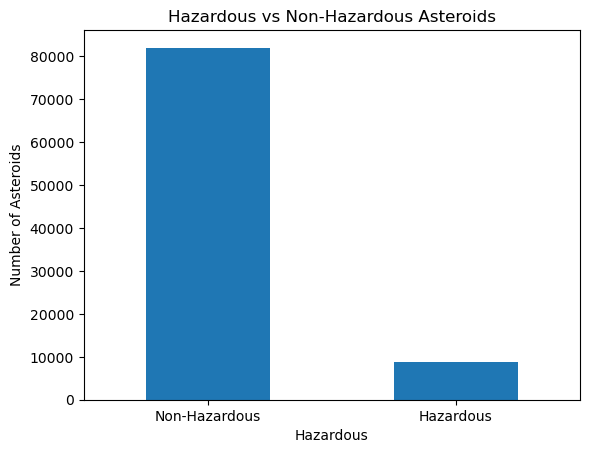

In [13]:
import matplotlib.pyplot as plt

df["hazardous"].value_counts().plot(kind="bar")

plt.title("Hazardous vs Non-Hazardous Asteroids")
plt.xlabel("Hazardous")
plt.ylabel("Number of Asteroids")
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Hazardous", "Hazardous"],
    rotation=0
)

plt.show()

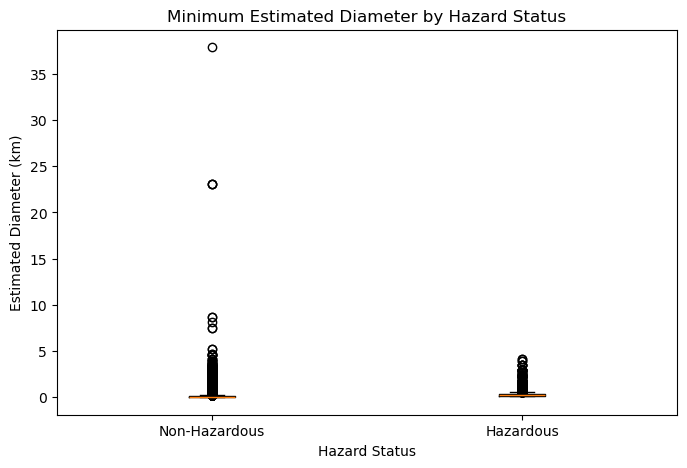

In [14]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["hazardous"] == False]["est_diameter_min"],
        df[df["hazardous"] == True]["est_diameter_min"]
    ],
    tick_labels=["Non-Hazardous", "Hazardous"]
)

plt.title("Minimum Estimated Diameter by Hazard Status")
plt.xlabel("Hazard Status")
plt.ylabel("Estimated Diameter (km)")

plt.show()

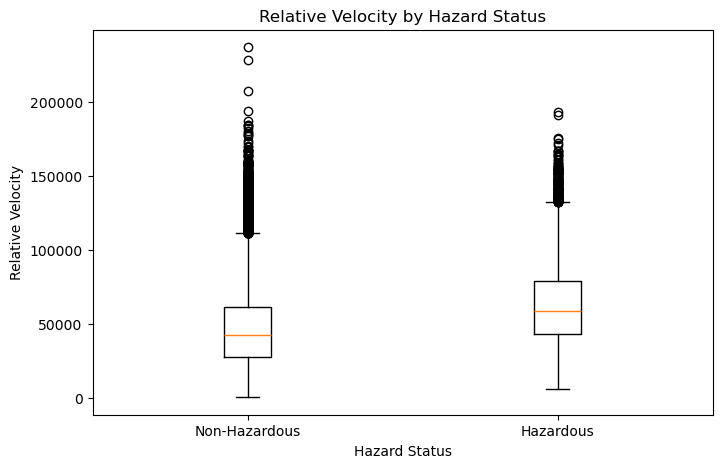

In [15]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df[df["hazardous"] == False]["relative_velocity"],
        df[df["hazardous"] == True]["relative_velocity"]
    ],
    tick_labels=["Non-Hazardous", "Hazardous"]
)

plt.title("Relative Velocity by Hazard Status")
plt.xlabel("Hazard Status")
plt.ylabel("Relative Velocity")

plt.show()

In [16]:
df.groupby("hazardous")["miss_distance"].describe()

,count,mean,std,min,25%,50%,75%,max
hazardous,,,,,,,,
False,81996.0,3.675609e+07,2.245904e+07,6745.532516,1.672851e+07,3.748745e+07,5.628455e+07,7.479865e+07
True,8840.0,3.994623e+07,2.111883e+07,143272.707499,2.172841e+07,4.098372e+07,5.852393e+07,7.479095e+07


In [17]:
df.groupby("hazardous")["absolute_magnitude"].describe()

,count,mean,std,min,25%,50%,75%,max
hazardous,,,,,,,,
False,81996.0,23.874199,2.801199,9.23,22.06000,24.1,25.90,33.2
True,8840.0,20.307598,1.341676,14.04,19.60775,20.6,21.36,22.4


In [18]:
# Compare average estimated diameter between hazardous
# and non-hazardous asteroids

diameter_comparison = df.groupby("hazardous")[
    ["est_diameter_min", "est_diameter_max"]
].mean()

diameter_comparison

,est_diameter_min,est_diameter_max
hazardous,,
False,0.109460,0.244760
True,0.294134,0.657704


In [19]:
# Compare relative velocity between hazardous
# and non-hazardous asteroids

velocity_comparison = df.groupby("hazardous")[
    "relative_velocity"
].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

velocity_comparison

,mean,median,std,min,max
hazardous,,,,,
False,46479.153953,42565.504033,24560.334742,203.346433,236990.128088
True,62794.337025,58658.010358,27175.110049,5908.291826,193386.975218


In [20]:
# Select numerical features
numerical_features = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude"
]

# Calculate the correlation matrix
correlation_matrix = df[numerical_features].corr()

# Display the correlation matrix
correlation_matrix.round(3)

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
est_diameter_min,1.000,1.000,0.222,0.142,-0.560
est_diameter_max,1.000,1.000,0.222,0.142,-0.560
relative_velocity,0.222,0.222,1.000,0.327,-0.354
miss_distance,0.142,0.142,0.327,1.000,-0.264
absolute_magnitude,-0.560,-0.560,-0.354,-0.264,1.000


In [21]:
# Inspect categorical and Boolean columns

categorical_columns = [
    "orbiting_body",
    "sentry_object",
    "hazardous"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


orbiting_body:
orbiting_body
Earth    90836
Name: count, dtype: int64

sentry_object:
sentry_object
False    90836
Name: count, dtype: int64

hazardous:
hazardous
False    81996
True      8840
Name: count, dtype: int64


In [22]:
# Create the initial machine-learning dataset
# without modifying the original dataframe.

feature_columns = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude"
]

target_column = "hazardous"

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Feature columns:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Feature columns:
['est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

Target column:
hazardous

Feature shape: (90836, 5)
Target shape: (90836,)


In [23]:
# Check the relationship between minimum and maximum diameter

diameter_ratio = (
    X["est_diameter_max"] / X["est_diameter_min"]
)

print("Diameter ratio statistics:")
print(diameter_ratio.describe())

print("\nNumber of unique ratio values:")
print(diameter_ratio.nunique())

print("\nFirst 10 diameter ratios:")
print(diameter_ratio.head(10))

Diameter ratio statistics:
count    9.083600e+04
mean     2.236068e+00
std      5.101698e-09
min      2.236068e+00
25%      2.236068e+00
50%      2.236068e+00
75%      2.236068e+00
max      2.236068e+00
dtype: float64

Number of unique ratio values:
1631

First 10 diameter ratios:
0    2.236068
1    2.236068
2    2.236068
3    2.236068
4    2.236068
5    2.236068
6    2.236068
7    2.236068
8    2.236068
9    2.236068
dtype: float64


In [24]:
# Remove the redundant maximum-diameter feature
# while keeping the original dataframe unchanged.

selected_features = [
    "est_diameter_min",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude"
]

X = df[selected_features].copy()
y = df["hazardous"].copy()

print("Selected features:")
for feature in X.columns:
    print("-", feature)

print("\nNumber of features:", X.shape[1])
print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Selected features:
- est_diameter_min
- relative_velocity
- miss_distance
- absolute_magnitude

Number of features: 4
Feature dataset shape: (90836, 4)
Target dataset shape: (90836,)


In [25]:
# ============================================================
# DATA PREPROCESSING & FEATURE PREPARATION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ------------------------------------------------------------
#  Select final features
# ------------------------------------------------------------
# We remove:
# - id: identifier, not a physical predictive feature
# - name: asteroid name, not a useful numerical predictor
# - orbiting_body: constant value (Earth)
# - sentry_object: constant value (False)
# - est_diameter_max: redundant with est_diameter_min
#
# We retain the physically meaningful numerical features.

selected_features = [
    "est_diameter_min",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude"
]

X = df[selected_features].copy()
y = df["hazardous"].copy()


# ------------------------------------------------------------
# Verify the selected dataset
# ------------------------------------------------------------

print("Selected features:")
print(X.columns.tolist())

print("\nFeature dataset shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)


# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------

print("\nMissing values in selected features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())


# ------------------------------------------------------------
#Encode the target variable
# ------------------------------------------------------------
# False -> 0 (Non-Hazardous)
# True  -> 1 (Hazardous)

y = y.astype(int)

print("\nEncoded target distribution:")
print(y.value_counts().sort_index())


# ------------------------------------------------------------
#  Split the dataset
# ------------------------------------------------------------
# Stratification preserves the original hazardous/non-hazardous
# class ratio in both training and testing datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# 4.6 Display train/test sizes
# ------------------------------------------------------------

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# ------------------------------------------------------------
#  Check class distribution after splitting
# ------------------------------------------------------------

print("\nTraining class distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting class distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))


# ------------------------------------------------------------
#  Scale numerical features
# ------------------------------------------------------------
# StandardScaler transforms each feature so that its training
# data has approximately mean = 0 and standard deviation = 1.
#
# IMPORTANT:
# The scaler is fitted ONLY on training data to avoid data leakage.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# Convert scaled arrays back to DataFrames
# ------------------------------------------------------------
# Keeping the column names makes later analysis easier.

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=selected_features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=selected_features,
    index=X_test.index
)


# ------------------------------------------------------------
# Verify scaling
# ------------------------------------------------------------

print("\nScaled training feature means:")
print(X_train_scaled.mean().round(4))

print("\nScaled training feature standard deviations:")
print(X_train_scaled.std().round(4))


# ------------------------------------------------------------
#  Final preprocessing summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETE")
print("=" * 60)

print("\nFinal features:")
print(selected_features)

print("\nFinal training shape:")
print(X_train_scaled.shape)

print("\nFinal testing shape:")
print(X_test_scaled.shape)

print("\nTarget classes:")
print("0 = Non-Hazardous")
print("1 = Hazardous")

print("\nClass imbalance remains intentionally preserved.")
print("We will address it during model development.")

Selected features:
['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

Feature dataset shape:
(90836, 4)

Target shape:
(90836,)

Missing values in selected features:
est_diameter_min      0
relative_velocity     0
miss_distance         0
absolute_magnitude    0
dtype: int64

Missing values in target:
0

Encoded target distribution:
hazardous
0    81996
1     8840
Name: count, dtype: int64

Training set:
X_train: (72668, 4)
y_train: (72668,)

Testing set:
X_test: (18168, 4)
y_test: (18168,)

Training class distribution:
hazardous
0    65596
1     7072
Name: count, dtype: int64
hazardous
0    90.27
1     9.73
Name: proportion, dtype: float64

Testing class distribution:
hazardous
0    16400
1     1768
Name: count, dtype: int64
hazardous
0    90.27
1     9.73
Name: proportion, dtype: float64

Scaled training feature means:
est_diameter_min      0.0
relative_velocity    -0.0
miss_distance        -0.0
absolute_magnitude   -0.0
dtype: float64

Scaled training f

In [26]:
# ============================================================
#  MODEL DEVELOPMENT
#  Baseline Model Training and Evaluation
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)


# ------------------------------------------------------------
#  Define baseline models
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}


# ------------------------------------------------------------
# Train and evaluate each model
# ------------------------------------------------------------

baseline_results = []

for model_name, model in models.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    # Train
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    # Store results
    baseline_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    # Print metrics
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Non-Hazardous", "Hazardous"],
            zero_division=0
        )
    )


# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------

baseline_results_df = pd.DataFrame(baseline_results)

print("\n" + "=" * 60)
print("BASELINE MODEL COMPARISON")
print("=" * 60)

print(
    baseline_results_df
    .sort_values("F1 Score", ascending=False)
    .round(4)
    .to_string(index=False)
)


Logistic Regression
Accuracy : 0.9033
Precision: 0.5209
Recall   : 0.0775
F1 Score : 0.1349
ROC-AUC  : 0.8812
PR-AUC   : 0.3590

Classification Report:
               precision    recall  f1-score   support

Non-Hazardous       0.91      0.99      0.95     16400
    Hazardous       0.52      0.08      0.13      1768

     accuracy                           0.90     18168
    macro avg       0.71      0.53      0.54     18168
 weighted avg       0.87      0.90      0.87     18168


Random Forest
Accuracy : 0.9146
Precision: 0.5949
Recall   : 0.3846
F1 Score : 0.4672
ROC-AUC  : 0.9320
PR-AUC   : 0.5875

Classification Report:
               precision    recall  f1-score   support

Non-Hazardous       0.94      0.97      0.95     16400
    Hazardous       0.59      0.38      0.47      1768

     accuracy                           0.91     18168
    macro avg       0.77      0.68      0.71     18168
 weighted avg       0.90      0.91      0.91     18168


Gradient Boosting
Accuracy : 0.91

In [27]:
# ============================================================
#  CLASS IMBALANCE HANDLING
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)


# ------------------------------------------------------------
#  Define imbalance-aware models
# ------------------------------------------------------------

balanced_models = {
    "Balanced Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ),

    "Balanced Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Balanced Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}


# ------------------------------------------------------------
#  Create sample weights for Gradient Boosting
# ------------------------------------------------------------
# Give the minority hazardous class a larger weight.

class_counts = y_train.value_counts()

weight_for_0 = 1.0
weight_for_1 = class_counts[0] / class_counts[1]

sample_weights = y_train.map({
    0: weight_for_0,
    1: weight_for_1
})


print("Class weight used for Non-Hazardous (0):", weight_for_0)
print("Class weight used for Hazardous (1):", round(weight_for_1, 4))


# ------------------------------------------------------------
#  Train and evaluate imbalance-aware models
# ------------------------------------------------------------

balanced_results = []

for model_name, model in balanced_models.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    # Gradient Boosting requires explicit sample weights.
    if model_name == "Balanced Gradient Boosting":
        model.fit(
            X_train_scaled,
            y_train,
            sample_weight=sample_weights
        )
    else:
        model.fit(
            X_train_scaled,
            y_train
        )

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )
    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    balanced_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    # Display metrics
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "Non-Hazardous",
                "Hazardous"
            ],
            zero_division=0
        )
    )


# ------------------------------------------------------------
#  Create comparison table
# ------------------------------------------------------------

balanced_results_df = pd.DataFrame(balanced_results)

print("\n" + "=" * 60)
print("IMBALANCE-AWARE MODEL COMPARISON")
print("=" * 60)

print(
    balanced_results_df
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
#  Combine baseline and balanced results
# ------------------------------------------------------------

all_model_results = pd.concat(
    [
        baseline_results_df,
        balanced_results_df
    ],
    ignore_index=True
)

print("\n" + "=" * 60)
print("ALL MODEL RESULTS")
print("=" * 60)

print(
    all_model_results
    .sort_values("F1 Score", ascending=False)
    .round(4)
    .to_string(index=False)
)

Class weight used for Non-Hazardous (0): 1.0
Class weight used for Hazardous (1): 9.2755

Balanced Logistic Regression
Accuracy : 0.7859
Precision: 0.3042
Recall   : 0.9321
F1 Score : 0.4587
ROC-AUC  : 0.8794
PR-AUC   : 0.3262

Classification Report:
               precision    recall  f1-score   support

Non-Hazardous       0.99      0.77      0.87     16400
    Hazardous       0.30      0.93      0.46      1768

     accuracy                           0.79     18168
    macro avg       0.65      0.85      0.66     18168
 weighted avg       0.92      0.79      0.83     18168


Balanced Random Forest
Accuracy : 0.9160
Precision: 0.6172
Recall   : 0.3603
F1 Score : 0.4550
ROC-AUC  : 0.9315
PR-AUC   : 0.5849

Classification Report:
               precision    recall  f1-score   support

Non-Hazardous       0.93      0.98      0.95     16400
    Hazardous       0.62      0.36      0.46      1768

     accuracy                           0.92     18168
    macro avg       0.78      0.67    

In [28]:
# ============================================================
#  — THRESHOLD TUNING
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Select the original Random Forest
# ------------------------------------------------------------

rf_model = models["Random Forest"]

# Get probability of Hazardous class
rf_probabilities = rf_model.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 2. Evaluate different probability thresholds
# ------------------------------------------------------------

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    y_threshold_pred = (
        rf_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_test,
            y_threshold_pred
        ),
        "Precision": precision_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        )
    })

threshold_results_df = pd.DataFrame(threshold_results)

print("=" * 70)
print("THRESHOLD PERFORMANCE — RANDOM FOREST")
print("=" * 70)

print(
    threshold_results_df
    .round(4)
    .to_string(index=False)
)

# ------------------------------------------------------------
# 3. Find threshold with highest F1 score
# ------------------------------------------------------------

best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1 Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("\n" + "=" * 70)
print("BEST F1 THRESHOLD")
print("=" * 70)

print(
    f"Threshold : {best_threshold:.2f}"
)

print(
    f"Accuracy  : {best_threshold_row['Accuracy']:.4f}"
)

print(
    f"Precision : {best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall    : {best_threshold_row['Recall']:.4f}"
)

print(
    f"F1 Score  : {best_threshold_row['F1 Score']:.4f}"
)

# ------------------------------------------------------------
#  Generate final Random Forest predictions
#    using the selected threshold
# ------------------------------------------------------------

y_rf_threshold_pred = (
    rf_probabilities >= best_threshold
).astype(int)

print("\n" + "=" * 70)
print("CONFUSION MATRIX — TUNED RANDOM FOREST")
print("=" * 70)

cm = confusion_matrix(
    y_test,
    y_rf_threshold_pred
)

print(cm)

print("\nConfusion Matrix Layout:")
print("[[True Negative, False Positive],")
print(" [False Negative, True Positive]]")

# ------------------------------------------------------------
# 5. Final metrics at tuned threshold
# ------------------------------------------------------------

final_accuracy = accuracy_score(
    y_test,
    y_rf_threshold_pred
)

final_precision = precision_score(
    y_test,
    y_rf_threshold_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_rf_threshold_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_rf_threshold_pred,
    zero_division=0
)

print("\n" + "=" * 70)
print("TUNED RANDOM FOREST PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")

print("\nThreshold tuning complete.")

THRESHOLD PERFORMANCE — RANDOM FOREST
 Threshold  Accuracy  Precision  Recall  F1 Score
      0.10    0.8260     0.3512  0.9304    0.5099
      0.15    0.8512     0.3826  0.8620    0.5300
      0.20    0.8702     0.4136  0.7992    0.5451
      0.25    0.8838     0.4413  0.7308    0.5503
      0.30    0.8939     0.4666  0.6329    0.5372
      0.35    0.9020     0.4970  0.5650    0.5289
      0.40    0.9089     0.5334  0.5057    0.5192
      0.45    0.9130     0.5675  0.4446    0.4986
      0.50    0.9146     0.5949  0.3846    0.4672
      0.55    0.9177     0.6472  0.3394    0.4453
      0.60    0.9178     0.6861  0.2868    0.4045
      0.65    0.9180     0.7368  0.2455    0.3683
      0.70    0.9182     0.8065  0.2098    0.3330
      0.75    0.9158     0.8310  0.1697    0.2818
      0.80    0.9141     0.8876  0.1340    0.2329
      0.85    0.9125     0.9202  0.1109    0.1979
      0.90    0.9111     0.9634  0.0894    0.1636

BEST F1 THRESHOLD
Threshold : 0.25
Accuracy  : 0.8838
Precisi

6.1 CONFUSION MATRIX — TUNED RANDOM FOREST


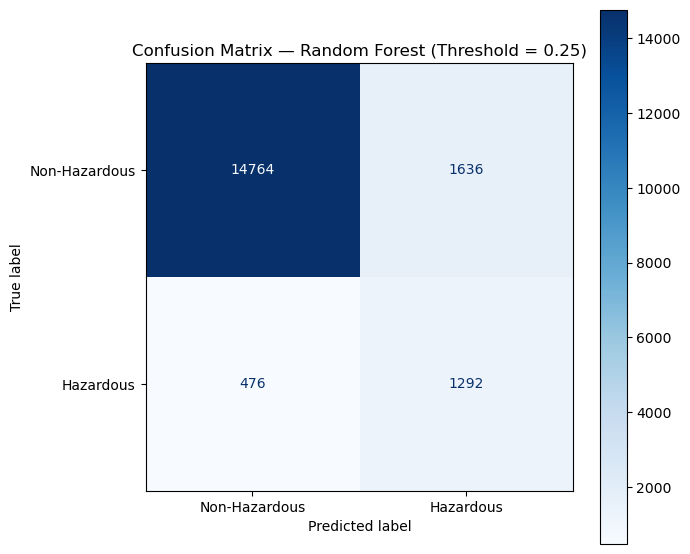


6.2 ROC CURVES


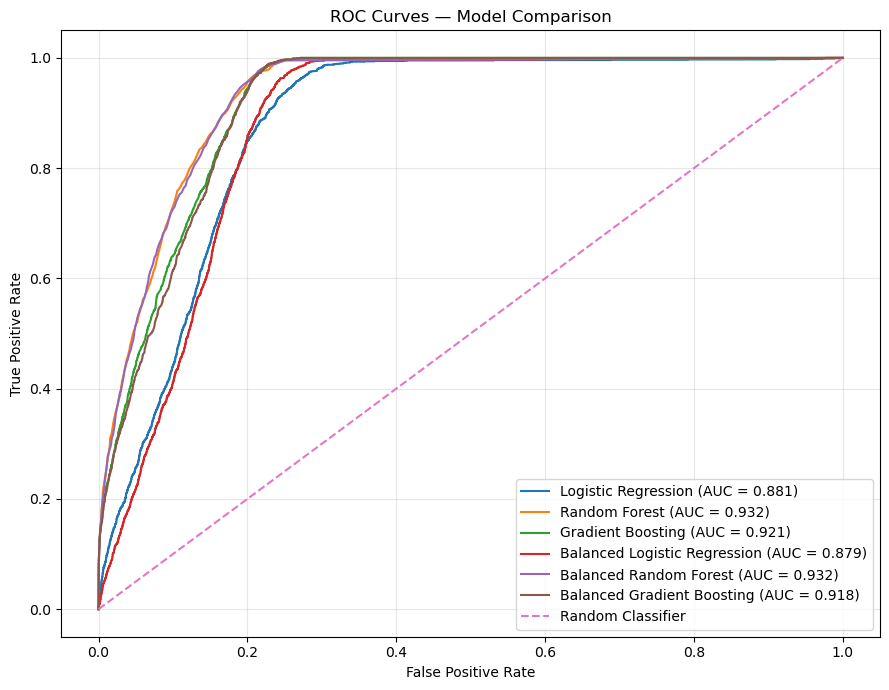


6.3 PRECISION-RECALL CURVES


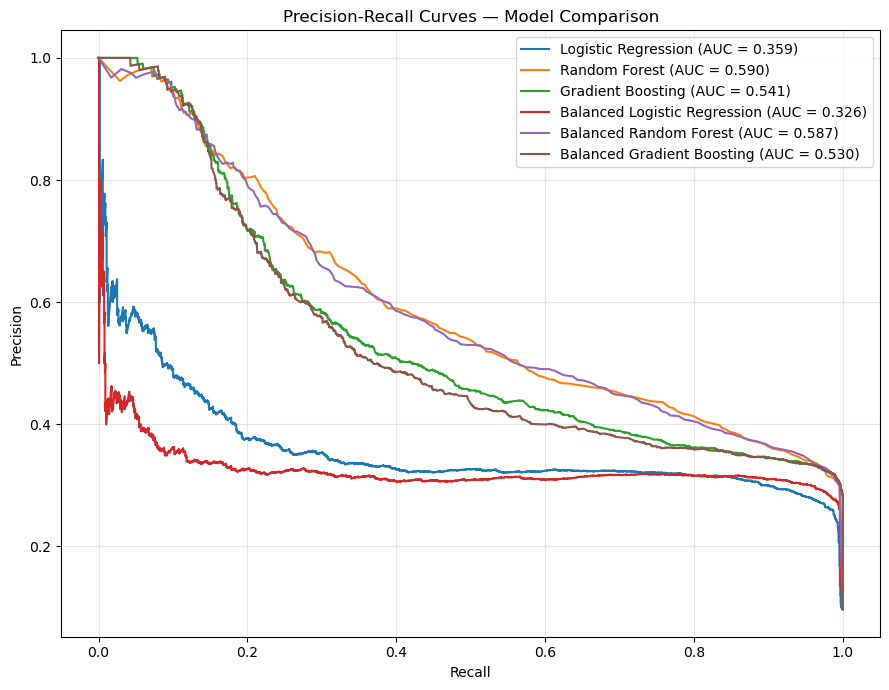


6.4 MODEL COMPARISON


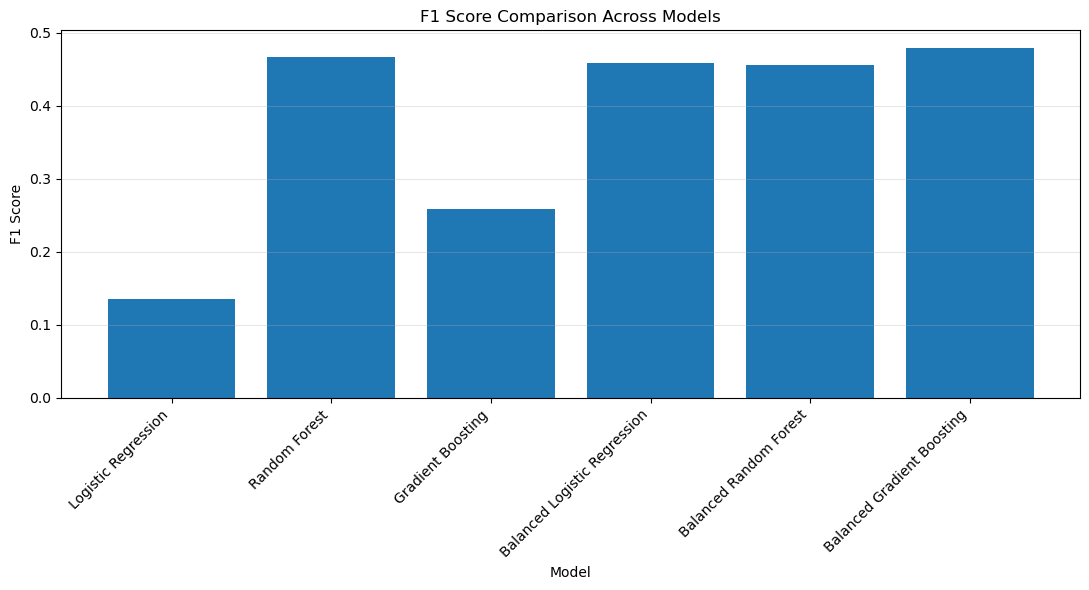


6.5 FINAL TUNED RANDOM FOREST EVALUATION
Classification threshold : 0.25
Accuracy                 : 0.8838
Precision                : 0.4413
Recall                   : 0.7308
F1 Score                 : 0.5503
ROC-AUC                  : 0.9320
PR-AUC                   : 0.5875

EVALUATION SUMMARY

The Random Forest model was evaluated using multiple metrics
because the target classes are imbalanced.

The classification threshold was adjusted from the default
0.50 to the F1-optimized threshold identified during threshold
tuning.

The evaluation includes:
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC



In [29]:
# ============================================================
# MODEL EVALUATION & VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

# ============================================================
# CONFUSION MATRIX — TUNED RANDOM FOREST
# ============================================================

print("=" * 70)
print("6.1 CONFUSION MATRIX — TUNED RANDOM FOREST")
print("=" * 70)

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_rf_threshold_pred,
    display_labels=["Non-Hazardous", "Hazardous"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title(
    f"Confusion Matrix — Random Forest (Threshold = {best_threshold:.2f})"
)

plt.tight_layout()
plt.show()


# ============================================================
# ROC CURVES
# ============================================================

print("\n" + "=" * 70)
print("6.2 ROC CURVES")
print("=" * 70)

# Store probability predictions for each model
model_probabilities = {}

for model_name, model in models.items():
    model_probabilities[model_name] = model.predict_proba(
        X_test_scaled
    )[:, 1]

for model_name, model in balanced_models.items():
    model_probabilities[model_name] = model.predict_proba(
        X_test_scaled
    )[:, 1]

plt.figure(figsize=(9, 7))

for model_name, probabilities in model_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
#  PRECISION-RECALL CURVES
# ============================================================

print("\n" + "=" * 70)
print("6.3 PRECISION-RECALL CURVES")
print("=" * 70)

plt.figure(figsize=(9, 7))

for model_name, probabilities in model_probabilities.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    pr_auc = auc(
        recall,
        precision
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AUC = {pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# MODEL COMPARISON — F1 SCORE
# ============================================================

print("\n" + "=" * 70)
print("6.4 MODEL COMPARISON")
print("=" * 70)

comparison_plot_df = all_model_results.copy()

plt.figure(figsize=(11, 6))

plt.bar(
    comparison_plot_df["Model"],
    comparison_plot_df["F1 Score"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("F1 Score Comparison Across Models")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
#  FINAL TUNED RANDOM FOREST METRICS
# ============================================================

print("\n" + "=" * 70)
print("6.5 FINAL TUNED RANDOM FOREST EVALUATION")
print("=" * 70)

print(f"Classification threshold : {best_threshold:.2f}")
print(f"Accuracy                 : {final_accuracy:.4f}")
print(f"Precision                : {final_precision:.4f}")
print(f"Recall                   : {final_recall:.4f}")
print(f"F1 Score                 : {final_f1:.4f}")

# ROC-AUC and PR-AUC remain probability-based metrics
final_roc_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

final_pr_auc = average_precision_score(
    y_test,
    rf_probabilities
)

print(f"ROC-AUC                  : {final_roc_auc:.4f}")
print(f"PR-AUC                   : {final_pr_auc:.4f}")


# ============================================================
# EVALUATION SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)

print("""
The Random Forest model was evaluated using multiple metrics
because the target classes are imbalanced.

The classification threshold was adjusted from the default
0.50 to the F1-optimized threshold identified during threshold
tuning.

The evaluation includes:
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC
""")


7.1 RANDOM FOREST FEATURE IMPORTANCE
           Feature  Importance
     miss_distance      0.2992
 relative_velocity      0.2682
  est_diameter_min      0.2244
absolute_magnitude      0.2082


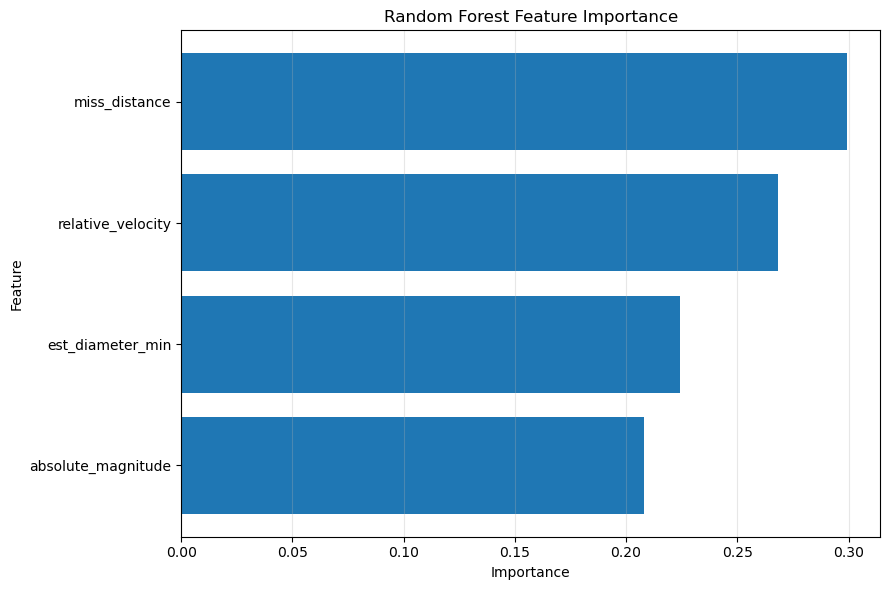


7.3 FEATURE IMPORTANCE PERCENTAGES
           Feature  Importance_Percentage
     miss_distance                  29.92
 relative_velocity                  26.82
  est_diameter_min                  22.44
absolute_magnitude                  20.82

7.4 EXPLAINABILITY SUMMARY
Most important feature according to the Random Forest: miss_distance
Importance: 29.92%

All selected features and their importance:
- miss_distance: 29.92%
- relative_velocity: 26.82%
- est_diameter_min: 22.44%
- absolute_magnitude: 20.82%

Feature importance analysis complete.


In [30]:
# ============================================================
#  FEATURE IMPORTANCE / EXPLAINABILITY
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
#  RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

print("=" * 70)
print("7.1 RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

feature_importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": rf_model.feature_importances_
})

feature_importance_df = (
    feature_importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance_df.round(4).to_string(index=False))


# ============================================================
#  FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
#  FEATURE IMPORTANCE PERCENTAGES
# ============================================================

feature_importance_df["Importance_Percentage"] = (
    feature_importance_df["Importance"] * 100
)

print("\n" + "=" * 70)
print("7.3 FEATURE IMPORTANCE PERCENTAGES")
print("=" * 70)

print(
    feature_importance_df[
        ["Feature", "Importance_Percentage"]
    ]
    .round(2)
    .to_string(index=False)
)


# ============================================================
# EXPLAINABILITY SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("7.4 EXPLAINABILITY SUMMARY")
print("=" * 70)

most_important_feature = feature_importance_df.iloc[0]

print(
    f"Most important feature according to the Random Forest: "
    f"{most_important_feature['Feature']}"
)

print(
    f"Importance: "
    f"{most_important_feature['Importance_Percentage']:.2f}%"
)

print("\nAll selected features and their importance:")

for _, row in feature_importance_df.iterrows():
    print(
        f"- {row['Feature']}: "
        f"{row['Importance_Percentage']:.2f}%"
    )

print("\nFeature importance analysis complete.")

In [31]:
# ============================================================
# FINAL MODEL & MODEL SAVING
# ============================================================

import joblib
import os
import pandas as pd

# ============================================================
#  TRAIN FINAL RANDOM FOREST MODEL
# ============================================================

print("=" * 70)
print("8.1 TRAINING FINAL RANDOM FOREST MODEL")
print("=" * 70)

final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_scaled,
    y_train
)

print("Final Random Forest trained successfully.")


# ============================================================
#  FINAL MODEL PROBABILITIES
# ============================================================

final_test_probabilities = final_model.predict_proba(
    X_test_scaled
)[:, 1]

final_test_predictions = (
    final_test_probabilities >= best_threshold
).astype(int)


# ============================================================
#  FINAL MODEL PERFORMANCE
# ============================================================

final_model_accuracy = accuracy_score(
    y_test,
    final_test_predictions
)

final_model_precision = precision_score(
    y_test,
    final_test_predictions,
    zero_division=0
)

final_model_recall = recall_score(
    y_test,
    final_test_predictions,
    zero_division=0
)

final_model_f1 = f1_score(
    y_test,
    final_test_predictions,
    zero_division=0
)

final_model_roc_auc = roc_auc_score(
    y_test,
    final_test_probabilities
)

final_model_pr_auc = average_precision_score(
    y_test,
    final_test_probabilities
)

print("\n" + "=" * 70)
print("8.3 FINAL MODEL PERFORMANCE")
print("=" * 70)

print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {final_model_accuracy:.4f}")
print(f"Precision : {final_model_precision:.4f}")
print(f"Recall    : {final_model_recall:.4f}")
print(f"F1 Score  : {final_model_f1:.4f}")
print(f"ROC-AUC   : {final_model_roc_auc:.4f}")
print(f"PR-AUC    : {final_model_pr_auc:.4f}")


# ============================================================
#  FINAL MODEL FEATURE IMPORTANCE
# ============================================================

final_feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": final_model.feature_importances_
})

final_feature_importance = (
    final_feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("8.4 FINAL MODEL FEATURE IMPORTANCE")
print("=" * 70)

print(
    final_feature_importance
    .round(4)
    .to_string(index=False)
)


# ============================================================
# SAVE MODEL AND SCALER
# ============================================================

model_filename = "hazardous_asteroid_random_forest.pkl"
scaler_filename = "hazardous_asteroid_scaler.pkl"

joblib.dump(
    final_model,
    model_filename
)

joblib.dump(
    scaler,
    scaler_filename
)

print("\n" + "=" * 70)
print("8.5 MODEL FILES SAVED")
print("=" * 70)

print(f"Model saved as : {model_filename}")
print(f"Scaler saved as: {scaler_filename}")


# ============================================================
# VERIFY SAVED FILES
# ============================================================

print("\n" + "=" * 70)
print("8.6 SAVED FILE VERIFICATION")
print("=" * 70)

print(
    f"{model_filename}: "
    f"{os.path.exists(model_filename)}"
)

print(
    f"{scaler_filename}: "
    f"{os.path.exists(scaler_filename)}"
)


# ============================================================
#  SAVE PROJECT CONFIGURATION
# ============================================================

model_config = {
    "features": selected_features,
    "classification_threshold": float(best_threshold),
    "target_mapping": {
        0: "Non-Hazardous",
        1: "Hazardous"
    },
    "model_type": "Random Forest Classifier",
    "n_estimators": 200,
    "random_state": 42
}

config_filename = "hazardous_asteroid_config.pkl"

joblib.dump(
    model_config,
    config_filename
)

print(
    f"Configuration saved as: {config_filename}"
)


# ============================================================
#  FINAL MODEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print("Model          : Random Forest Classifier")
print("Trees          : 200")
print("Random State   : 42")
print(f"Threshold      : {best_threshold:.2f}")

print("\nFeatures used:")
for feature in selected_features:
    print(f"- {feature}")

print("\nTarget:")
print("0 = Non-Hazardous")
print("1 = Hazardous")

print("\nFinal model preparation complete.")

8.1 TRAINING FINAL RANDOM FOREST MODEL
Final Random Forest trained successfully.

8.3 FINAL MODEL PERFORMANCE
Threshold : 0.25
Accuracy  : 0.8838
Precision : 0.4413
Recall    : 0.7308
F1 Score  : 0.5503
ROC-AUC   : 0.9320
PR-AUC    : 0.5875

8.4 FINAL MODEL FEATURE IMPORTANCE
           Feature  Importance
     miss_distance      0.2992
 relative_velocity      0.2682
  est_diameter_min      0.2244
absolute_magnitude      0.2082

8.5 MODEL FILES SAVED
Model saved as : hazardous_asteroid_random_forest.pkl
Scaler saved as: hazardous_asteroid_scaler.pkl

8.6 SAVED FILE VERIFICATION
hazardous_asteroid_random_forest.pkl: True
hazardous_asteroid_scaler.pkl: True
Configuration saved as: hazardous_asteroid_config.pkl

FINAL MODEL SUMMARY
Model          : Random Forest Classifier
Trees          : 200
Random State   : 42
Threshold      : 0.25

Features used:
- est_diameter_min
- relative_velocity
- miss_distance
- absolute_magnitude

Target:
0 = Non-Hazardous
1 = Hazardous

Final model preparatio

In [32]:
## ============================================================
# PREDICTION UI / DEPLOYMENT
# ============================================================

import joblib
import pandas as pd

# ------------------------------------------------------------
#  LOAD SAVED MODEL
# ------------------------------------------------------------

loaded_model = joblib.load(
    "hazardous_asteroid_random_forest.pkl"
)

loaded_scaler = joblib.load(
    "hazardous_asteroid_scaler.pkl"
)

loaded_config = joblib.load(
    "hazardous_asteroid_config.pkl"
)

prediction_threshold = loaded_config["classification_threshold"]
prediction_features = loaded_config["features"]

print("=" * 70)
print("HAZARDOUS ASTEROID PREDICTION SYSTEM")
print("=" * 70)

print("\nModel loaded successfully.")
print("Model:", loaded_config["model_type"])
print("Classification threshold:", prediction_threshold)

# ------------------------------------------------------------
#  PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_asteroid(
    diameter,
    velocity,
    miss_distance,
    magnitude
):

    input_data = pd.DataFrame(
        [[
            diameter,
            velocity,
            miss_distance,
            magnitude
        ]],
        columns=prediction_features
    )

    # Scale input
    input_scaled = loaded_scaler.transform(input_data)

    # Preserve feature names
    input_scaled = pd.DataFrame(
        input_scaled,
        columns=prediction_features
    )

    # Get probability
    probability = loaded_model.predict_proba(
        input_scaled
    )[0, 1]

    # Apply selected threshold
    prediction = int(
        probability >= prediction_threshold
    )

    return prediction, probability


# ------------------------------------------------------------
# INTERACTIVE PREDICTION INTERFACE
# ------------------------------------------------------------

print("\nEnter asteroid information below.")

try:

    diameter = float(
        input("\nEstimated diameter: ")
    )

    velocity = float(
        input("Relative velocity: ")
    )

    miss_distance = float(
        input("Miss distance: ")
    )

    magnitude = float(
        input("Absolute magnitude: ")
    )

    # Input validation
    if diameter <= 0:
        raise ValueError("Diameter must be greater than 0.")

    if velocity <= 0:
        raise ValueError("Velocity must be greater than 0.")

    if miss_distance <= 0:
        raise ValueError("Miss distance must be greater than 0.")

    # Prediction
    prediction, probability = predict_asteroid(
        diameter,
        velocity,
        miss_distance,
        magnitude
    )

    print("\n" + "=" * 70)
    print("PREDICTION RESULT")
    print("=" * 70)

    print(
        f"\nHazard probability: "
        f"{probability * 100:.2f}%"
    )

    print(
        f"Classification threshold: "
        f"{prediction_threshold:.2f}"
    )

    if prediction == 1:
        print("\nPrediction: HAZARDOUS")
    else:
        print("\nPrediction: NON-HAZARDOUS")

    print("\nInput values:")
    print(f"Estimated diameter : {diameter}")
    print(f"Relative velocity  : {velocity}")
    print(f"Miss distance      : {miss_distance}")
    print(f"Absolute magnitude : {magnitude}")

    print("\n" + "=" * 70)

except ValueError as error:

    print("\nInput Error:", error)

except Exception as error:

    print("\nPrediction Error:", error)

print("\nPrediction interface completed.")

HAZARDOUS ASTEROID PREDICTION SYSTEM

Model loaded successfully.
Model: Random Forest Classifier
Classification threshold: 0.25000000000000006

Enter asteroid information below.



Estimated diameter:  0.4
Relative velocity:  47000
Miss distance:  38000000
Absolute magnitude:  30



PREDICTION RESULT

Hazard probability: 39.00%
Classification threshold: 0.25

Prediction: HAZARDOUS

Input values:
Estimated diameter : 0.4
Relative velocity  : 47000.0
Miss distance      : 38000000.0
Absolute magnitude : 30.0


Prediction interface completed.
